In [2]:
import xarray as xr

IN_PATH = "../data/specifichumidity_wind_1000-925hpa_2026-02-19.nc"

ds = xr.open_dataset(IN_PATH)

# Adjust these names if your dataset uses different ones.
LEVEL_DIM = "pressure_level"
U_NAME = "u"
V_NAME = "v"

# Sanity checks (fail fast if something is off)
if LEVEL_DIM not in ds.dims and LEVEL_DIM not in ds.coords:
    raise KeyError(f"Expected pressure dimension/coord '{LEVEL_DIM}' not found. Found dims={list(ds.dims)}, coords={list(ds.coords)}")
if U_NAME not in ds.data_vars or V_NAME not in ds.data_vars:
    raise KeyError(f"Expected variables '{U_NAME}' and '{V_NAME}' not found. Found data_vars={list(ds.data_vars)}")

level_vals = ds[LEVEL_DIM].values
if 1000 not in level_vals:
    raise ValueError(f"1000 hPa not present in '{LEVEL_DIM}'. Levels present: {level_vals}")

ds_1000 = ds.sel({LEVEL_DIM: 1000})

u_1000 = ds_1000[U_NAME]
v_1000 = ds_1000[V_NAME]

u_1000, v_1000


(<xarray.DataArray 'u' (valid_time: 1464, latitude: 721, longitude: 1440)> Size: 6GB
 [1519983360 values with dtype=float32]
 Coordinates:
   * valid_time      (valid_time) datetime64[ns] 12kB 2021-11-01 ... 2021-12-3...
     expver          (valid_time) <U4 23kB ...
   * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
   * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
     number          int64 8B ...
     pressure_level  float64 8B 1e+03
 Attributes: (12/31)
     GRIB_paramId:                             131
     GRIB_dataType:                            an
     GRIB_numberOfPoints:                      1038240
     GRIB_typeOfLevel:                         isobaricInhPa
     GRIB_stepUnits:                           1
     GRIB_stepType:                            instant
     ...                                       ...
     GRIB_shortName:                           u
     GRIB_totalNumber:                         0
     GRIB_u

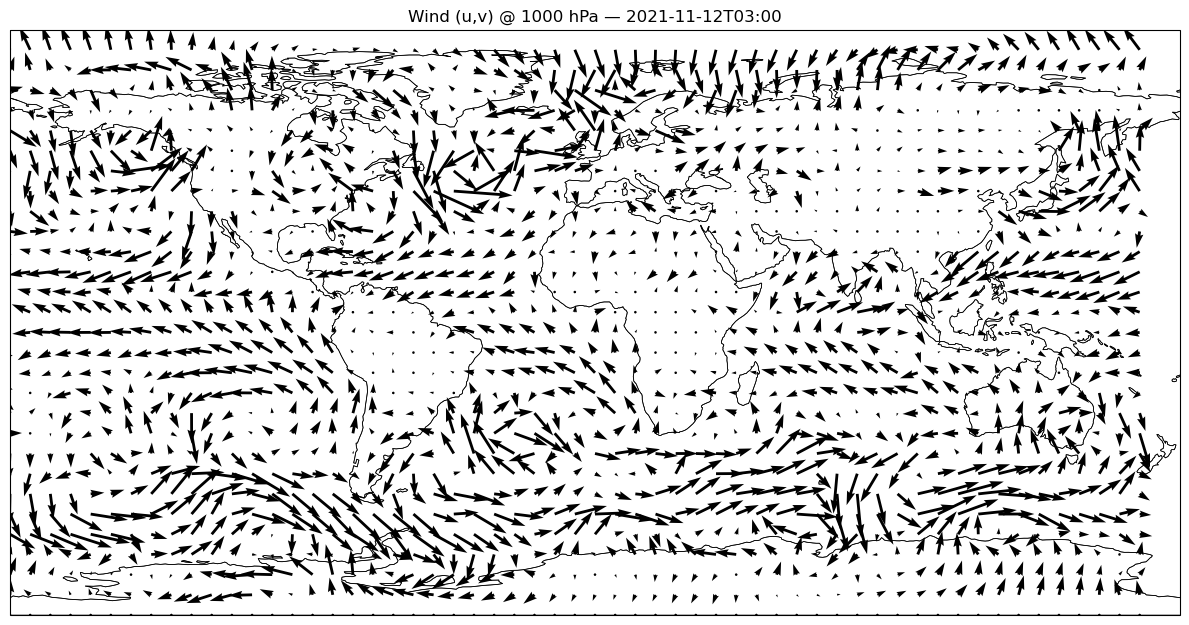

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

TIME_DIM = "valid_time"

if TIME_DIM not in ds_1000.dims and TIME_DIM not in ds_1000.coords:
    raise KeyError(
        f"Expected time coord '{TIME_DIM}' not found. Found dims={list(ds_1000.dims)}, coords={list(ds_1000.coords)}"
    )

def pick_coord(ds, options):
    for name in options:
        if name in ds.coords or name in ds.dims:
            return name
    raise KeyError(f"None of {options} found in dims/coords. dims={list(ds.dims)}, coords={list(ds.coords)}")

LAT = pick_coord(ds_1000, ["latitude", "lat", "y"])
LON = pick_coord(ds_1000, ["longitude", "lon", "x"])

target = np.datetime64("2021-11-12T03:00")

times = ds_1000[TIME_DIM].values
if target not in times:
    tmin = np.min(times)
    tmax = np.max(times)
    raise ValueError(
        f"Requested time {target} not present in file. "
        f"Available range: {tmin} .. {tmax}. "
        f"Example available times (first 5): {times[:5]}"
    )

u_t = u_1000.sel({TIME_DIM: target})
v_t = v_1000.sel({TIME_DIM: target})

lats = ds_1000[LAT].values
lons = ds_1000[LON].values

# --- Roll longitudes to [-180, 180) and reorder data accordingly ---
lons_180 = ((lons + 180.0) % 360.0) - 180.0          # wrap
order = np.argsort(lons_180)                         # make monotonic increasing
lons_180 = lons_180[order]

# Apply the same lon reordering to u/v
# (assumes u_t/v_t are [lat, lon] at this point; if not, xarray will still handle isel correctly)
u_t = u_t.isel({LON: order})
v_t = v_t.isel({LON: order})

# Subsample for readability/performance
ny = len(lats)
nx = len(lons_180)
stride_y = max(1, ny // 40)
stride_x = max(1, nx // 40)

lats_s = lats[::stride_y]
lons_s = lons_180[::stride_x]
U = u_t.values[::stride_y, ::stride_x]
V = v_t.values[::stride_y, ::stride_x]

X, Y = np.meshgrid(lons_s, lats_s)

# --- Cartopy plot ---
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=proj)

ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.4)
ax.coastlines(linewidth=0.6)

ax.set_extent(
    [float(lons_180.min()), float(lons_180.max()), float(lats.min()), float(lats.max())],
    crs=proj,
)

ax.quiver(X, Y, U, V, transform=proj, regrid_shape=30)

ax.set_title(f"Wind (u,v) @ 1000 hPa — {str(target)}")
plt.tight_layout()
plt.show()


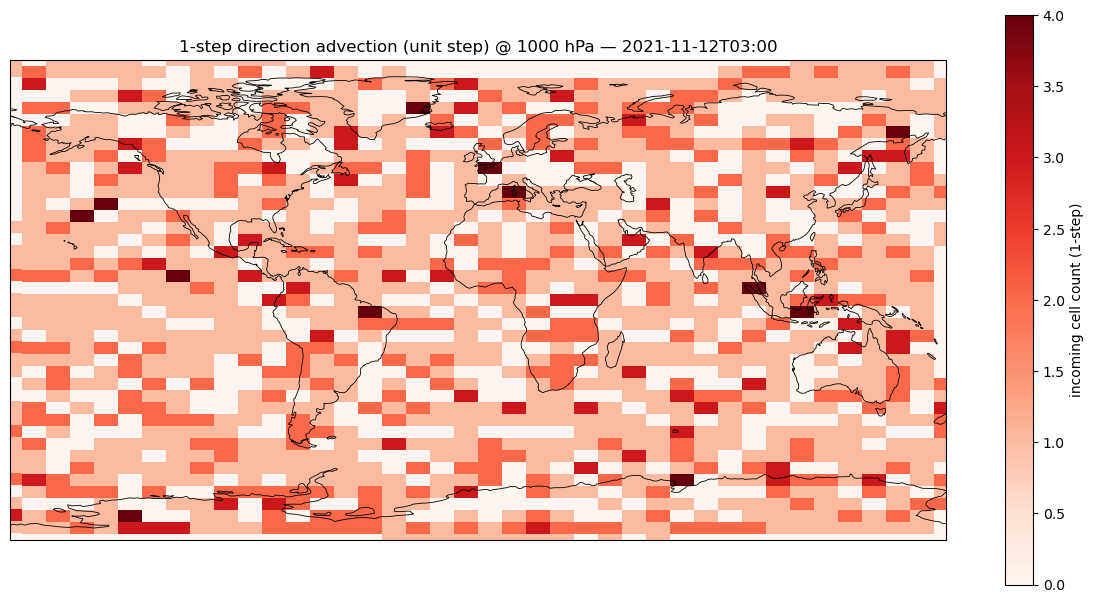

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assumes previous cell produced:
#   lats_s, lons_s, U, V  (all subsampled and lon-rolled to [-180,180))
# where U,V have shape (len(lats_s), len(lons_s))

ny, nx = U.shape

# --- 8-direction quantization (E, NE, N, NW, W, SW, S, SE) ---
# angle = atan2(v,u) in radians, map to k in {0..7} using nearest 45-deg sector
angle = np.arctan2(V, U)
k = (np.round(angle / (np.pi / 4)).astype(int) % 8)

# dx,dy lookup for each sector k
# k=0: E, 1: NE, 2: N, 3: NW, 4: W, 5: SW, 6: S, 7: SE
dx_lut = np.array([+1, +1,  0, -1, -1, -1,  0, +1], dtype=int)
dy_lut = np.array([ 0, -1, -1, -1,  0, +1, +1, +1], dtype=int)  # -1 is "north" (smaller row index)

dx = dx_lut[k]
dy = dy_lut[k]

# If wind is exactly zero, don't move it (optional)
still = (U == 0) & (V == 0)
dx = np.where(still, 0, dx)
dy = np.where(still, 0, dy)

# --- accumulate destination counts ---
ii, jj = np.indices((ny, nx))
ii2 = ii + dy
jj2 = jj + dx

inside = (ii2 >= 0) & (ii2 < ny) & (jj2 >= 0) & (jj2 < nx)

counts = np.zeros((ny, nx), dtype=np.int32)
np.add.at(counts, (ii2[inside], jj2[inside]), 1)

# --- plot on Cartopy ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=proj)

ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.4)
ax.coastlines(linewidth=0.6)

ax.set_extent(
    [float(lons_s.min()), float(lons_s.max()), float(lats_s.min()), float(lats_s.max())],
    crs=proj,
)

# heatmap: "how many cells' direction lands here after 1-step move"
m = ax.pcolormesh(
    lons_s,
    lats_s,
    counts,
    transform=proj,
    shading="auto",
    cmap="Reds",
)

plt.colorbar(m, ax=ax, shrink=0.85, label="incoming cell count (1-step)")
ax.set_title(f"1-step direction advection (unit step) @ 1000 hPa — {str(target)}")
plt.tight_layout()
plt.show()


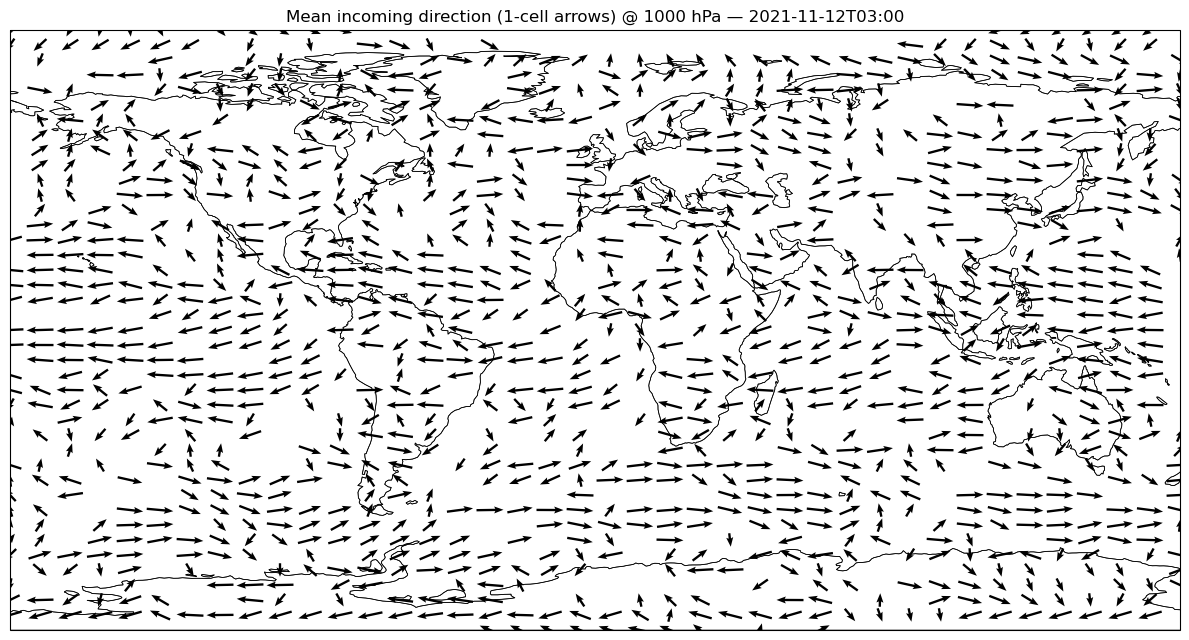

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assumes you already have (from prior cells):
#   lats_s, lons_s, U, V, target
# and U,V have shape (ny, nx)

ny, nx = U.shape

# Direction angle (radians) for each source cell
theta = np.arctan2(V, U)

# Quantize to 8-neighborhood and compute 1-step destination
k = (np.round(theta / (np.pi / 4)).astype(int) % 8)
dx_lut = np.array([+1, +1,  0, -1, -1, -1,  0, +1], dtype=int)
dy_lut = np.array([ 0, -1, -1, -1,  0, +1, +1, +1], dtype=int)

dx = dx_lut[k]
dy = dy_lut[k]

# Optional: if calm, don't move (prevents arbitrary angle noise)
still = (U == 0) & (V == 0)
dx = np.where(still, 0, dx)
dy = np.where(still, 0, dy)

ii, jj = np.indices((ny, nx))
ii2 = ii + dy
jj2 = jj + dx
inside = (ii2 >= 0) & (ii2 < ny) & (jj2 >= 0) & (jj2 < nx)

# Accumulators for destination cells:
counts = np.zeros((ny, nx), dtype=np.int32)
sum_cos = np.zeros((ny, nx), dtype=np.float64)
sum_sin = np.zeros((ny, nx), dtype=np.float64)

dest_i = ii2[inside]
dest_j = jj2[inside]
theta_src = theta[inside]

np.add.at(counts, (dest_i, dest_j), 1)
np.add.at(sum_cos, (dest_i, dest_j), np.cos(theta_src))
np.add.at(sum_sin, (dest_i, dest_j), np.sin(theta_src))

# Circular mean direction at each destination
mask = counts > 0
mean_theta = np.full((ny, nx), np.nan, dtype=np.float64)
mean_theta[mask] = np.arctan2(sum_sin[mask], sum_cos[mask])

# Unit vectors for quiver
Umean = np.zeros((ny, nx), dtype=np.float64)
Vmean = np.zeros((ny, nx), dtype=np.float64)
Umean[mask] = np.cos(mean_theta[mask])
Vmean[mask] = np.sin(mean_theta[mask])

# Subsample arrows for readability
stride_y = max(1, ny // 30)
stride_x = max(1, nx // 30)

Uq = Umean[::stride_y, ::stride_x]
Vq = Vmean[::stride_y, ::stride_x]
Cq = counts[::stride_y, ::stride_x]
Xq, Yq = np.meshgrid(lons_s[::stride_x], lats_s[::stride_y])

# Only draw arrows where there was at least one incoming cell
min_count_for_arrow = 1
show = Cq >= min_count_for_arrow

# --- Plot (quiver only) ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=proj)

ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.4)
ax.coastlines(linewidth=0.6)

ax.set_extent(
    [float(lons_s.min()), float(lons_s.max()), float(lats_s.min()), float(lats_s.max())],
    crs=proj,
)

# Make arrows ~1 grid cell long (direction only)
dlon = float(np.median(np.diff(lons_s)))
dlat = float(np.median(np.diff(lats_s)))

arrow_len_cells = 0.9  # 1.0 = about one cell; tweak 0.5..2.0
Uplot = Uq * dlon * arrow_len_cells
Vplot = Vq * dlat * arrow_len_cells

ax.quiver(
    Xq[show], Yq[show],
    Uplot[show], Vplot[show],
    transform=proj,
    angles="xy",
    scale_units="xy",
    scale=1,          # IMPORTANT: now lengths are already in degrees
    width=0.002,      # make visible
    headwidth=3,
    headlength=4,
    headaxislength=3.5,
    pivot="middle",
)

ax.set_title(f"Mean incoming direction (1-cell arrows) @ 1000 hPa — {str(target)}")
plt.tight_layout()
plt.show()
